Quantum Circuits

Wires -> qubits  
Gates -> operations on those qubits

Convention used in Qiskit:  
The topmost qubit in a circuit diagram has index 0 and the rightmost position in a tuple of qubits.  
The bottommost qubit has the highest index abd the leftmost position in a tuple.   

This program creates an example circuit with two qubits and applies gates on it to make a Bell state.  

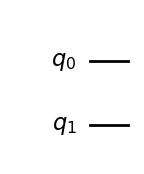

In [24]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from IPython.display import display, Latex


example_circuit = QuantumCircuit(2)
display(example_circuit.draw(output="mpl"))

<IPython.core.display.Latex object>

[0.70710678+0.j,0.        +0.j,0.        +0.j,0.70710678+0.j]

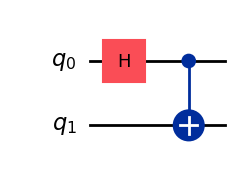

In [25]:
# Creating Bell state (a maximally entangled two-qubit state)
example_circuit.h(0) # applying hadamard gate on q0
example_circuit.cx(0,1) # applying cnot gate with control on q0
# Here:
# 1. Hadamard creates superposition on qubit 0.
# 2. CNOT entangles qubit 0 and qubit 1.

# Representation in Dirac (bra-ket) notation
state = Statevector.from_instruction(example_circuit)
display(state.draw('latex'))
display(state.draw('text'))

# diagram of the circuit
display(example_circuit.draw(output="mpl"))

# this has created the |Φ+> Bell state.

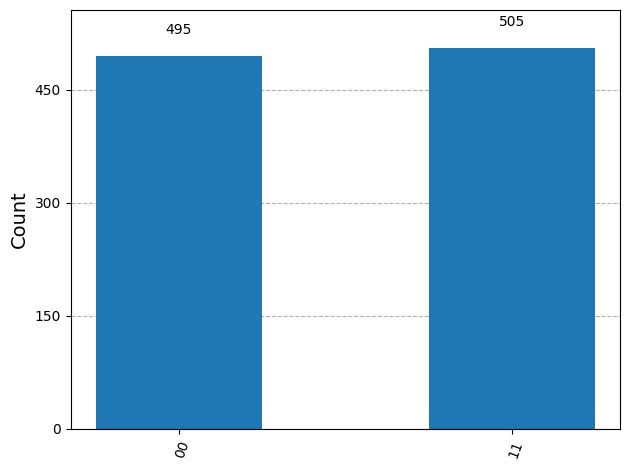

In [26]:

example_circuit.measure_all()

from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

def run_and_count(circuit, backend, shots=500):
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

backend = AerSimulator()
# We use a simulator to plot the results, instead of an 
# actual quantum computer.
counts = run_and_count(example_circuit, backend, shots=1000)

plot_histogram(counts)

# Since the qubits are entangled, measuring one determines the other.
# Therefore only 00 and 11 appear. We get 00 and 11 with almost equal
# counts, as expected.